In [18]:
!pip install geopandas pandas matplotlib folium scipy statsmodels libpysal esda mapclassify fiona requests openpyxl jupyter ipykernel pygeohydro

## 1. Library Imports and Path Definitions


In [19]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
import fiona
import requests
import json
import os
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from libpysal.weights import Queen
from esda.moran import Moran

print("All libraries loaded successfully")

# Paths
xlsx_path = "/mnt/e/Portfolio Files/nebraska-nitrate/NE_Clearinghouse_Full_Public_05-09-2026.xlsx"

# NASS API key -- load from environment variable, never hardcode
nass_api_key = os.environ.get("NASS_API_KEY")
if not nass_api_key:
    print("WARNING: NASS_API_KEY environment variable not set")
else:
    print("NASS API key loaded")

All libraries loaded successfully
NASS API key loaded


## 2. Load County Boundaries

In [20]:
# Load Nebraska county boundaries from Census TIGER
nebraska = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)
nebraska = nebraska[nebraska['STATEFP'] == '31']

print(f"Loaded {len(nebraska)} counties")
nebraska.head()

Loaded 93 counties


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,0500000US31039,Cuming,Cuming County,06,H1,G4020,NaN,NaN,NaN,A,1477563029,10772508,+41.9158651,-096.7885168,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
3,31,109,00835876,31109,0500000US31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NaN,A,2169269688,22850324,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,0500000US31129,Nuckolls,Nuckolls County,06,H1,G4020,NaN,NaN,NaN,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."
40,31,101,00835872,31101,0500000US31101,Keith,Keith County,06,H1,G4020,NaN,NaN,NaN,A,2750729944,123802447,+41.1942448,-101.6444493,"POLYGON ((-102.05546 41.29967, -102.05545 41.3..."
41,31,137,00835890,31137,0500000US31137,Phelps,Phelps County,06,H1,G4020,NaN,NaN,NaN,A,1397985736,1709313,+40.5163647,-099.4065568,"POLYGON ((-99.17949 40.52501, -99.17948 40.524..."


## 3. Load HUC-8 Watershed Boundaries

In [21]:
from pygeohydro import WBD

wbd = WBD("huc8")
huc8 = wbd.bygeom(nebraska.dissolve().to_crs('EPSG:4326').geometry.iloc[0])

print(f"Loaded {len(huc8)} HUC-8 watersheds")
huc8.head()

/home/kyle/workspace/kkrumm/nebraska-nitrate-analysis/.venv/lib/python3.12/site-packages/pygeoogc/core.py:293: UserWarning: Found 1 failed request. Retrying ...
  resp = self._cleanup_resp(resp, payloads)


Loaded 142 HUC-8 watersheds


,geometry,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,globalid,shape_Length,shape_Area
0,"POLYGON ((-104.56468 42.64857, -104.56496 42.6...",155,{A618E96C-FFA7-4F93-B4FD-D1314C66F0D9},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1723803860000,"204647,835997",3299417.44,13352.28,"NE,WY",10180009,Middle North Platte-Scotts Bluff,{78A64AAE-2B47-4E19-9542-8FA650CB8340},1.528399e+06,2.409709e+10
1,"POLYGON ((-100.39426 44.50081, -100.39623 44.5...",395,{C67F85A4-B74A-499F-9CD4-8F6B528F2311},NaN,NaN,NaN,None,1476189274000,NaN,2731188.43,11052.74,"NE,SD",10140101,Fort Randall Reservoir,{EF0D2785-75ED-4720-B1C8-3C6F439EAF5B},1.456680e+06,2.115417e+10
2,"POLYGON ((-104.00168 41.95746, -104.00446 41.9...",405,{69513500-E836-407B-80AF-CF254935CACD},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1723803860000,830140,1090510.03,4413.14,"NE,WY",10180012,Horse,{5D5DC488-22E4-49B4-A217-83F900949E21},6.303431e+05,7.903952e+09
3,"POLYGON ((-97.21176 41.28185, -97.21197 41.282...",456,{9E50ED38-C561-4D47-AE60-48AF00F82381},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1723803860000,485505,708699.69,2868.01,NE,10270201,Upper Big Blue,{B8903096-BD50-4EDD-917D-BE841FF4BA2B},5.008663e+05,5.047696e+09
4,"POLYGON ((-101.01549 41.72186, -101.01557 41.7...",457,{6750EC7C-B4F9-4D4C-B57F-B47B1BAE8335},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1723803860000,"835915,827749",2137920.86,8651.87,NE,10200101,Middle Platte-Buffalo,{32599243-03B5-4552-8162-9E72DE48224A},1.314882e+06,1.517796e+10


## 4. Plot Watersheds

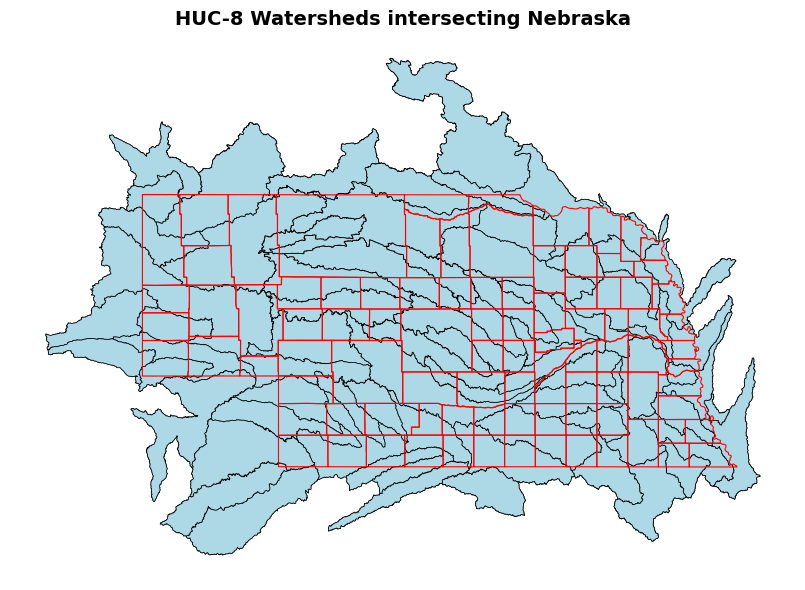

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

huc8.plot(ax=ax, facecolor='lightblue', edgecolor='black', linewidth=0.5)
nebraska.to_crs(huc8.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.8)

ax.set_title('HUC-8 Watersheds intersecting Nebraska', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5. Clip Watersheds to Nebraska Boundary

In [23]:
# Clip HUC-8 to Nebraska boundary
nebraska_boundary = nebraska.dissolve().to_crs(huc8.crs)
huc8_ne = gpd.clip(huc8, nebraska_boundary)

print(f"{len(huc8_ne)} HUC-8 watersheds clipped to Nebraska")

142 HUC-8 watersheds clipped to Nebraska


## 6. Load Nitrate Data

In [24]:
# Load nitrate data from Clearinghouse
print("\nLoading Clearinghouse data...")
facility = pd.read_excel(xlsx_path, sheet_name='Facility')
sample = pd.read_excel(xlsx_path, sheet_name='Sample')
result = pd.read_excel(xlsx_path, sheet_name='Result')

print(f"Facility: {len(facility):,} wells")
print(f"Sample: {len(sample):,} samples")
print(f"Result: {len(result):,} results")


Loading Clearinghouse data...


/home/kyle/workspace/kkrumm/nebraska-nitrate-analysis/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/kyle/workspace/kkrumm/nebraska-nitrate-analysis/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/kyle/workspace/kkrumm/nebraska-nitrate-analysis/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Facility: 37,612 wells
Sample: 162,359 samples
Result: 493,548 results


## 7. Filter results to Nitrate from 2015-2024

In [27]:
# Filter to nitrate only (ParamID 22)
nitrate_results = result[result['ParamID'] == 22].copy()
print(f"Nitrate results: {len(nitrate_results):,}")

# Parse sample dates and filter to 2015-2024
sample['SampleDate'] = pd.to_datetime(sample['SampleDate'])
sample_recent = sample[
    (sample['SampleDate'].dt.year >= 2015) &
    (sample['SampleDate'].dt.year <= 2024)
].copy()
print(f"Samples in 2015-2024 window: {len(sample_recent):,}")

# Join result -> sample -> facility
nitrate = nitrate_results.merge(sample_recent[['SampleID', 'FacilityID', 'SampleDate']], on='SampleID', how='inner')
nitrate = nitrate.merge(
    facility[['FacilityID', 'Latitude (Decimal Degrees)', 'Longitude (Decimal Degrees)']],
    left_on='FacilityID_y',
    right_on='FacilityID',
    how='inner'
)

print(f"Joined nitrate records: {len(nitrate):,}")
nitrate.head()

Nitrate results: 156,443
Samples in 2015-2024 window: 41,164
Joined nitrate records: 40,627


,ResultID,FacilityID_x,SampleID,Analytical Method ID-System,ParamID,Concentration,Units,StatisticalAnalyteValue,Result Detection Condition,Reporting Limit,...,Quality Flag,Modify Date,Modify User,Fraction Type,Laboratory,FacilityID_y,SampleDate,FacilityID,Latitude (Decimal Degrees),Longitude (Decimal Degrees)
0,323822,29155,104438,1220,22,0.1,mg/l,0.1,NR,0.1,...,5.0,6/18/2021 2:20:04 PM,ClearinghouseMigration,UNK,NaN,29155,2018-10-22 00:00:00,29155,42.704618,-97.291083
1,192965,7376,72703,1220,22,14.7,mg/l,14.7,NR,0.1,...,4.0,6/18/2021 2:20:04 PM,ClearinghouseMigration,UNK,NaN,7376,2017-06-22 00:00:00,7376,42.326321,-98.386012
2,239475493,136231,32635457,327,22,6.7,mg/l,6.7,PAQL,0.1,...,3.0,2/20/2025 2:00:00 PM,UploadID: 801,UNFIL,NaN,136231,2020-07-22 12:00:00,136231,41.057050,-98.139336
3,109621,14567,50154,1220,22,21.1,mg/l,21.1,NR,0.1,...,4.0,6/18/2021 2:20:04 PM,ClearinghouseMigration,UNK,NaN,14567,2019-08-13 00:00:00,14567,41.867068,-98.542844
4,266076,9653,89693,1220,22,12.3,mg/l,12.3,NR,0.1,...,4.0,6/18/2021 2:20:04 PM,ClearinghouseMigration,UNK,NaN,9653,2017-09-29 00:00:00,9653,41.516454,-97.745817


## 8. Average Nitrate per Well, convert to GeoDataFrame 

In [29]:
nitrate['Concentration'] = pd.to_numeric(nitrate['Concentration'], errors='coerce')

# Average nitrate concentration per well
well_avg = nitrate.groupby('FacilityID')['Concentration'].mean().reset_index()
well_avg.columns = ['FacilityID', 'avg_nitrate']

# Get unique well locations
well_locations = nitrate[['FacilityID', 'Latitude (Decimal Degrees)', 'Longitude (Decimal Degrees)']].drop_duplicates('FacilityID')

# Merge averages onto locations
wells = well_avg.merge(well_locations, on='FacilityID')

# Convert to GeoDataFrame
wells_gdf = gpd.GeoDataFrame(
    wells,
    geometry=gpd.points_from_xy(wells['Longitude (Decimal Degrees)'], wells['Latitude (Decimal Degrees)']),
    crs='EPSG:4326'
)

print(f"{len(wells_gdf)} wells with average nitrate concentrations")
print(f"Nitrate range: {wells_gdf['avg_nitrate'].min():.2f} to {wells_gdf['avg_nitrate'].max():.2f} mg/L")
print(f"Mean: {wells_gdf['avg_nitrate'].mean():.2f} mg/L")
wells_gdf.head()

18658 wells with average nitrate concentrations
Nitrate range: 0.00 to 166.00 mg/L
Mean: 7.24 mg/L


,FacilityID,avg_nitrate,Latitude (Decimal Degrees),Longitude (Decimal Degrees),geometry
0,4,2.6,40.390342,-98.520246,POINT (-98.52025 40.39034)
1,8,1.2,40.449981,-98.574721,POINT (-98.57472 40.44998)
2,9,3.5,40.653396,-98.518523,POINT (-98.51852 40.6534)
3,21,6.0,40.381032,-98.370284,POINT (-98.37028 40.38103)
4,22,7.3,40.411932,-98.680890,POINT (-98.68089 40.41193)


## Export Wells to GeoJSON - Ran once

In [ ]:
# # Export wells to GeoJSON -- run once
# try:
#     wells_gdf = gpd.read_file('wells_nitrate.geojson')
#     print(f"Loaded {len(wells_gdf)} wells from GeoJSON")
# except:
#     wells_gdf.to_file('wells_nitrate.geojson', driver='GeoJSON')
#     print(f"Exported {len(wells_gdf)} wells to wells_nitrate.geojson")


Exported 18658 wells to wells_nitrate.geojson


## 10. Plot Well Locations over Nebraska

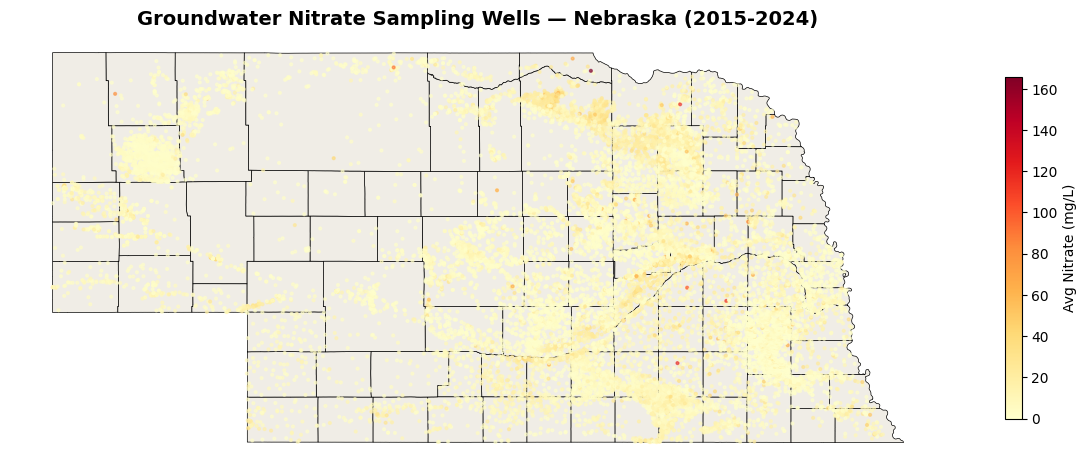

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

nebraska.to_crs('EPSG:4326').plot(
    ax=ax,
    facecolor='#f0ede6',
    edgecolor='black',
    linewidth=0.5
)

wells_gdf.plot(
    ax=ax,
    column='avg_nitrate',
    cmap='YlOrRd',
    markersize=4,
    alpha=0.6,
    legend=True,
    legend_kwds={'label': 'Avg Nitrate (mg/L)', 'shrink': 0.6}
)

ax.set_title('Groundwater Nitrate Sampling Wells — Nebraska (2015-2024)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 11. Spatial join wells to watershed, aggregate mean nitrate per watershet

In [34]:
# Reload clean HUC-8 to avoid column conflicts from previous runs
huc8_ne = gpd.clip(
    huc8.to_crs('EPSG:4326'),
    nebraska.dissolve().to_crs('EPSG:4326')
)

# Spatial join wells to HUC-8 watersheds
wells_proj = wells_gdf.to_crs(huc8_ne.crs)
wells_huc8 = gpd.sjoin(wells_proj, huc8_ne[['huc8', 'name', 'geometry']], how='inner', predicate='within')

# Aggregate mean nitrate per watershed
huc8_nitrate = wells_huc8.groupby('huc8')['avg_nitrate'].agg(['mean', 'count']).reset_index()
huc8_nitrate.columns = ['huc8', 'mean_nitrate', 'well_count']

# Merge onto HUC-8 geometry and deduplicate
huc8_ne = huc8_ne.merge(huc8_nitrate, on='huc8', how='left')
huc8_ne = huc8_ne.drop_duplicates(subset='huc8').reset_index(drop=True)

print(f"Watersheds after dedup: {len(huc8_ne)}")
print(f"Watersheds with nitrate data: {huc8_ne['mean_nitrate'].notna().sum()} of {len(huc8_ne)}")
print(f"Nitrate range: {huc8_ne['mean_nitrate'].min():.2f} to {huc8_ne['mean_nitrate'].max():.2f} mg/L")
huc8_ne[['huc8', 'name', 'mean_nitrate', 'well_count']].sort_values('mean_nitrate', ascending=False).head(10)

Watersheds after dedup: 71
Watersheds with nitrate data: 67 of 71
Nitrate range: 1.20 to 28.69 mg/L


,huc8,name,mean_nitrate,well_count
69,10170104,Ponca,28.694000,20.0
65,10150007,Lower Niobrara,18.119987,1018.0
40,10240005,Tarkio-Wolf,14.813750,16.0
57,10200103,Middle Platte-Prairie,14.323000,1118.0
0,10250003,South Fork Republican,12.129000,4.0
68,10170101,Lewis and Clark Lake,11.902984,902.0
36,10270205,Lower Big Blue,11.216667,6.0
64,10220002,North Fork Elkhorn,10.859896,1774.0
61,10210009,Loup,10.442386,2716.0
56,10270201,Upper Big Blue,10.117072,424.0


## Nitrate Choropleth map by watershed, with areas over 10 mg/L threshold

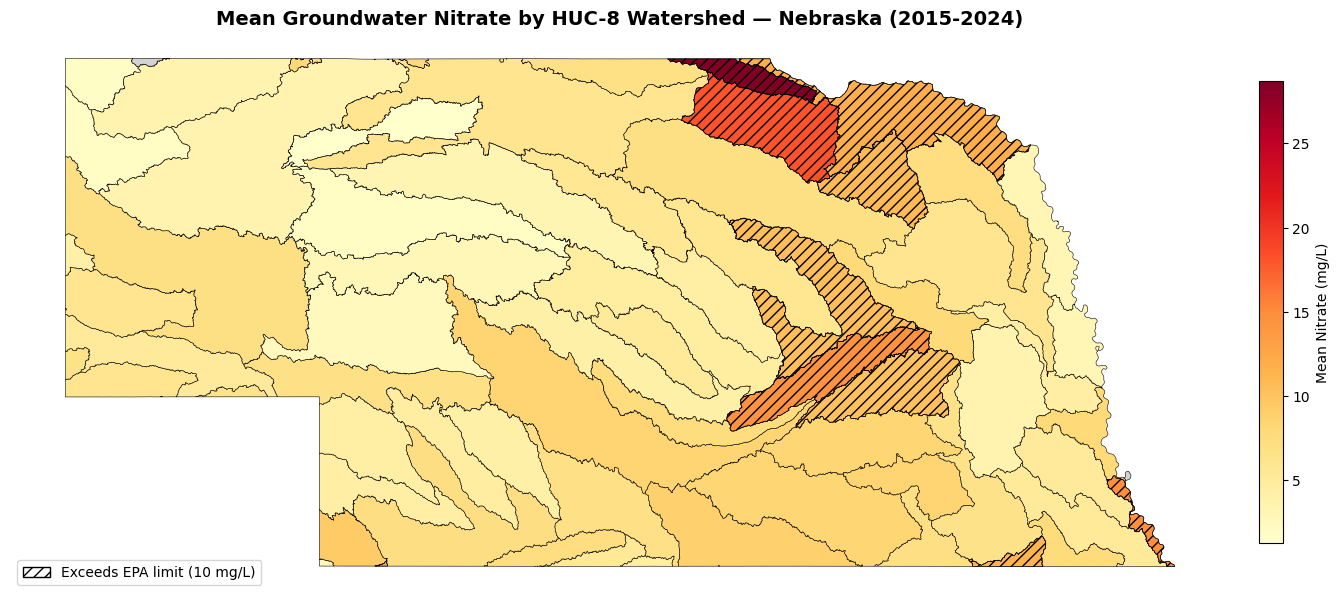

In [43]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(15, 8))

huc8_plot = huc8_ne.to_crs('EPSG:4326')

huc8_plot.plot(
    column='mean_nitrate',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={
        'label': 'Mean Nitrate (mg/L)',
        'shrink': 0.6,
        'pad': 0.02
    },
    edgecolor='black',
    linewidth=0.4,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)

# Hatch watersheds exceeding EPA 10 mg/L threshold
huc8_plot[huc8_plot['mean_nitrate'] >= 10].plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=0.4,
    hatch='///'
)

ax.set_title('Mean Groundwater Nitrate by HUC-8 Watershed — Nebraska (2015-2024)', fontsize=14, fontweight='bold')
ax.set_axis_off()

# Legend
threshold_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='Exceeds EPA limit (10 mg/L)')
ax.legend(handles=[threshold_patch], loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig('nebraska_nitrate_watershed.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Query NASS API for livesotck counts by Nebraska county

In [35]:
import urllib.parse

base_url = "https://quickstats.nass.usda.gov/api/api_GET/"

def query_nass(commodity, category, data_item):
    params = {
        "key": nass_api_key,
        "source_desc": "CENSUS",
        "sector_desc": "ANIMALS & PRODUCTS",
        "commodity_desc": commodity,
        "statisticcat_desc": category,
        "short_desc": data_item,
        "agg_level_desc": "COUNTY",
        "state_alpha": "NE",
        "year": "2022",
        "format": "JSON"
    }
    r = requests.get(base_url, params=params)
    data = r.json()
    if 'data' not in data:
        print(f"No data returned for {commodity}: {data}")
        return pd.DataFrame()
    df = pd.DataFrame(data['data'])
    df['Value'] = pd.to_numeric(df['Value'].str.replace(',', ''), errors='coerce')
    return df[['county_name', 'Value']].rename(columns={'Value': commodity.lower()})

# Query cattle, hogs, poultry
cattle = query_nass("CATTLE", "INVENTORY", "CATTLE, INCL CALVES - INVENTORY")
hogs = query_nass("HOGS", "INVENTORY", "HOGS - INVENTORY")
poultry = query_nass("POULTRY TOTALS", "INVENTORY", "POULTRY TOTALS, INCL TURKEYS & MISC - INVENTORY")

print(f"Cattle: {len(cattle)} counties")
print(f"Hogs: {len(hogs)} counties")
print(f"Poultry: {len(poultry)} counties")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [41]:
r = requests.get(base_url, params={
    "key": nass_api_key,
    "source_desc": "CENSUS",
    "commodity_desc": "CATTLE",
    "agg_level_desc": "COUNTY",
    "state_alpha": "NE",
    "year": "2022",
    "format": "JSON"
})
print(r.status_code)
print(r.text[:200])

504
<html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>Microsoft-Azure-Application-Gateway/v2</center>
</body>
</html>



## Moran's I Nitrate

In [44]:
from libpysal.weights import Queen
from esda.moran import Moran

# Reproject to projected CRS for spatial weights
huc8_proj = huc8_ne.to_crs('EPSG:32614')

# Drop watersheds with no nitrate data
huc8_nitrate_clean = huc8_proj.dropna(subset=['mean_nitrate'])

# Build spatial weights matrix
w = Queen.from_dataframe(huc8_nitrate_clean, use_index=True)
w.transform = 'r'

# Run Moran's I for nitrate
moran_nitrate = Moran(huc8_nitrate_clean['mean_nitrate'], w)

print("Moran's I -- Groundwater Nitrate")
print(f"  I statistic:  {moran_nitrate.I:.4f}")
print(f"  p-value:      {moran_nitrate.p_sim:.4f}")
print(f"  z-score:      {moran_nitrate.z_sim:.4f}")

Moran's I -- Groundwater Nitrate
  I statistic:  0.3097
  p-value:      0.0010
  z-score:      4.4156
